# Intelligent Pricing & Discount Optimization Recommends dynamic pricing based on customer segments, historical data, and market competition. Suggests optimal discount levels to maximize margins without losing deals.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1. Data Extraction

In [ ]:
# note : change the path to your local system
# data = pd.read_csv('/Users/do0rr8m/Desktop/test/pricing_optimization_synthetic_data.csv')
GITHUB_RAW_URL_FOR_FILE = "https://raw.githubusercontent.com/rahilkhan-acadmic/APAIML-GradedMiniProject/refs/heads/develop/AIChampion/pricing_optimization_synthetic_data.csv"
data = pd.read_csv(GITHUB_RAW_URL_FOR_FILE)

In [ ]:

data.head()

,customer_id,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%
0,1,Mid-Market,16766.73,4295.60,5,Low Competition,0.35,18134.40,-8.16
1,2,SMB,3935.22,23641.78,18,Moderate Competition,0.27,798.22,79.72
2,3,SMB,5717.46,14027.11,10,Moderate Competition,0.82,4836.93,15.40
3,4,Mid-Market,22666.75,21800.27,6,Moderate Competition,0.25,21663.38,4.43
4,5,Enterprise,15947.87,9545.20,1,High Competition,0.87,18088.41,-13.42


## Step 2. Data Analysis

In [ ]:
data.shape

(200, 9)

In [ ]:
data.describe()

,customer_id,historical_price,competitor_price,purchase_frequency_last_6m,demand_score,recommended_price,optimal_discount_%
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,13600.628200,14400.281450,9.610000,0.610100,13819.267750,9.627200
std,57.879185,6739.027476,7436.872946,5.470607,0.244655,8204.185966,34.456972
min,1.000000,2116.420000,2062.270000,1.000000,0.200000,-1263.030000,-23.680000
25%,50.750000,8013.635000,7983.587500,5.000000,0.407500,6835.887500,-9.122500
50%,100.500000,14457.720000,14514.670000,9.000000,0.620000,14777.050000,-1.805000
75%,150.250000,19070.585000,21428.980000,14.000000,0.822500,20515.357500,12.175000
max,200.000000,24781.620000,25993.170000,19.000000,1.000000,29103.240000,154.180000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 200 non-null    int64  
 1   customer_segment            200 non-null    object 
 2   historical_price            200 non-null    float64
 3   competitor_price            200 non-null    float64
 4   purchase_frequency_last_6m  200 non-null    int64  
 5   market_condition            200 non-null    object 
 6   demand_score                200 non-null    float64
 7   recommended_price           200 non-null    float64
 8   optimal_discount_%          200 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 14.2+ KB


## Step 3. Feature Engineering

In [ ]:
# 1. Dropping the column "customer_id"

data.drop(columns=['customer_id'], axis=1, inplace=True)

# 2. One hot Encoding of the Categorical Data (customer segment and market condition)
data_ohe = pd.get_dummies(data=data, columns=['customer_segment', 'market_condition'], drop_first=True)


In [ ]:
data_ohe

,historical_price,competitor_price,purchase_frequency_last_6m,demand_score,recommended_price,optimal_discount_%,customer_segment_Mid-Market,customer_segment_SMB,market_condition_Low Competition,market_condition_Moderate Competition
0,16766.73,4295.60,5,0.35,18134.40,-8.16,True,False,True,False
1,3935.22,23641.78,18,0.27,798.22,79.72,False,True,False,True
2,5717.46,14027.11,10,0.82,4836.93,15.40,False,True,False,True
3,22666.75,21800.27,6,0.25,21663.38,4.43,True,False,False,True
4,15947.87,9545.20,1,0.87,18088.41,-13.42,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
195,23407.42,13269.87,15,0.76,26145.24,-11.70,True,False,False,False
196,21743.49,17954.90,15,0.35,21659.47,0.39,False,True,False,True
197,11866.86,5970.14,1,0.91,13724.45,-15.65,False,True,False,False
198,19270.03,6453.39,7,0.97,23003.91,-19.38,False,True,False,False


In [ ]:
x  = data_ohe.drop('competitor_price', axis=1)
y = data_ohe[['competitor_price']]

In [ ]:
# 3. Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(x)

## Step 4. Model Building

In [ ]:
# 1. Train - Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)

In [ ]:
# 2. Base Model : Linear Regression

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

lin_model.fit(x_train, y_train)

y_pred_lin = lin_model.predict(x_test)

In [ ]:
# 3. Advance Model Tree Based : Decision Tree

from sklearn.tree import DecisionTreeRegressor

dec_model = DecisionTreeRegressor()

dec_model.fit(x_train, y_train)

y_pred_dec = dec_model.predict(x_test)

In [ ]:
# 4. Advance Model XGBoost :
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor()

gbr_model.fit(x_train, y_train)

y_pred_gbr = gbr_model.predict(x_test)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


## Step 5. Model Evaluation

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score

# 1. Linear Regression Model

print(mean_squared_error(y_pred_lin, y_test))
print(mean_absolute_error(y_pred_lin, y_test))
print(root_mean_squared_error(y_pred_lin, y_test))
print(r2_score(y_pred_lin, y_test))

5414111.772565323
1789.1359031821723
2326.8243965897645
0.887584853356954


In [ ]:
# 2. Decision Tree

print(mean_squared_error(y_pred_dec, y_test))
print(mean_absolute_error(y_pred_dec, y_test))
print(root_mean_squared_error(y_pred_dec, y_test))
print(r2_score(y_pred_dec, y_test))

21831780.58644
3784.0696666666668
4672.449099395305
0.5800959238229841


In [ ]:
# 3. Gradient Boosting

print(mean_squared_error(y_pred_gbr, y_test))
print(mean_absolute_error(y_pred_gbr, y_test))
print(root_mean_squared_error(y_pred_gbr, y_test))
print(r2_score(y_pred_gbr, y_test))

7078250.858171029
2099.3068297213827
2660.498234949805
0.807949745427332


## We found that "Linear Regression" model is perforning better on the evalution metrics.

In [ ]:
d = pd.DataFrame(data=[dec_model.feature_names_in_, dec_model.feature_importances_]).T

In [ ]:
d.columns = ['Feat_name', 'Feat_imp']

## Feature Importance model-wise

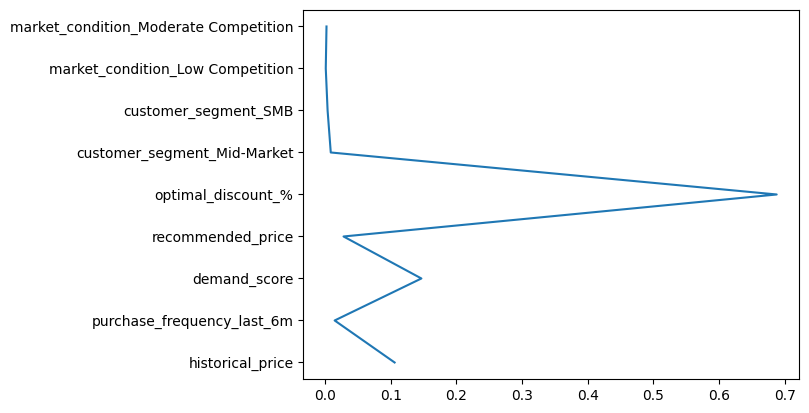

In [ ]:
plt.plot(d['Feat_imp'], d['Feat_name'])